# Exercise 6: ClinicalBERT Fine-tuning and Embedding Visualization

This notebook fine-tunes a ClinicalBERT model on medical abstracts and visualizes word embeddings using PCA.

### Install required libraries

Installs the Python packages required for this notebook: `transformers`, `datasets`, `evaluate`, `scikit-learn`, and `torch`.

In [1]:
!pip install transformers datasets evaluate scikit-learn torch

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.1/84.1 kB 5.6 MB/s eta 0:00:00


### Fine-tuning ClinicalBERT on medical abstracts

Loads the medical abstracts dataset, preprocesses and tokenizes the data, initializes `emilyalsentzer/Bio_ClinicalBERT` for sequence classification, configures training, fine-tunes the model, evaluates it, and runs a short inference demo.

In [ ]:
from datasets import load_dataset
from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    DataCollatorWithPadding,
    TrainingArguments,
    Trainer,
)
import evaluate
import numpy as np

# 1. Identify the Domain-Specific LLM (Pre-trained on MIMIC-III clinical notes)
model_name = "emilyalsentzer/Bio_ClinicalBERT"

# 2. Load the FULL dataset
print("Loading the complete medical abstracts dataset...")
dataset = load_dataset("TimSchopf/medical_abstracts", "default")

train_dataset = dataset["train"].shuffle(seed=42)
valid_dataset = dataset["test"].shuffle(seed=42)

id2label = {
    0: "Neoplasms",
    1: "Digestive system diseases",
    2: "Nervous system diseases",
    3: "Cardiovascular diseases",
    4: "General pathological conditions"
}
label2id = {v: k for k, v in id2label.items()}

# 3. Preprocessing: Rename columns and shift labels down by 1 to prevent CUDA errors
train_dataset = train_dataset.rename_column("medical_abstract", "text")
train_dataset = train_dataset.rename_column("condition_label", "label")
valid_dataset = valid_dataset.rename_column("medical_abstract", "text")
valid_dataset = valid_dataset.rename_column("condition_label", "label")

def adjust_labels(batch):
    batch["label"] = [label - 1 for label in batch["label"]]
    return batch

print("Adjusting labels to zero-index...")
train_dataset = train_dataset.map(adjust_labels, batched=True)
valid_dataset = valid_dataset.map(adjust_labels, batched=True)

# 4. Tokenization
tokenizer = AutoTokenizer.from_pretrained(model_name)

def tokenize_function(examples):
    return tokenizer(examples["text"], truncation=True, padding="max_length", max_length=128)

print("Tokenizing data...")
train_dataset = train_dataset.map(tokenize_function, batched=True)
valid_dataset = valid_dataset.map(tokenize_function, batched=True)

data_collator = DataCollatorWithPadding(tokenizer=tokenizer)

# Initialize the ClinicalBERT model
model = AutoModelForSequenceClassification.from_pretrained(
    model_name,
    num_labels=len(id2label),
    id2label=id2label,
    label2id=label2id
)

# 5. Advanced Evaluation Metrics
accuracy = evaluate.load("accuracy")
f1 = evaluate.load("f1")
precision = evaluate.load("precision")
recall = evaluate.load("recall")

def compute_metrics(eval_pred):
    logits, labels = eval_pred
    preds = np.argmax(logits, axis=-1)
    return {
        "accuracy": accuracy.compute(predictions=preds, references=labels)["accuracy"],
        "f1_weighted": f1.compute(predictions=preds, references=labels, average="weighted")["f1"],
        "precision_weighted": precision.compute(predictions=preds, references=labels, average="weighted", zero_division=0)["precision"],
        "recall_weighted": recall.compute(predictions=preds, references=labels, average="weighted")["recall"]
    }

# 6. Training Configuration
training_args = TrainingArguments(
    output_dir="./clinicalbert-medical-final",
    learning_rate=2e-5,
    per_device_train_batch_size=16,
    per_device_eval_batch_size=16,
    num_train_epochs=3,
    weight_decay=0.01,
    eval_strategy="epoch",
    save_strategy="epoch",
    load_best_model_at_end=True,
    logging_steps=100,
    report_to="none"
)

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=valid_dataset,
    processing_class=tokenizer,
    data_collator=data_collator,
    compute_metrics=compute_metrics,
)

# Execute Fine-tuning
print("Starting full fine-tuning. This will take approximately 15-20 minutes...")
trainer.train()

# Evaluate the final model
print("Evaluating final model metrics...")
metrics = trainer.evaluate()
print("\nFINAL EVALUATION METRICS:")
print(metrics)

# Inference Demo
print("\n--- INFERENCE DEMO ---")
sample_docs = [
    "The patient presented with a malignant tumor in the lower lobe of the right lung, requiring immediate oncology consultation.",
    "Symptoms include chronic acid reflux, severe heartburn, and difficulty swallowing after meals."
]

inputs = tokenizer(sample_docs, truncation=True, padding=True, max_length=128, return_tensors="pt")
inputs = {k: v.to(model.device) for k, v in inputs.items()}
outputs = model(**inputs)
preds = outputs.logits.argmax(dim=-1).tolist()

for text, pred in zip(sample_docs, preds):
    print(f"\nTEXT: {text}\nPREDICTED LABEL: {id2label[pred]}")

Loading the complete medical abstracts dataset...


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


README.md: 0.00B [00:00, ?B/s]

data/train-00000-of-00001.parquet:   0%|          | 0.00/7.67M [00:00<?, ?B/s]

data/test-00000-of-00001.parquet:   0%|          | 0.00/1.94M [00:00<?, ?B/s]

...

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['bert.embeddings.LayerNorm.weight', 'bert.embeddings.LayerNorm.bias', 'bert.encoder.layer.0.attention.output.LayerNorm.weight', 'bert.encoder.layer.0.attention.output.LayerNorm.bias', 'bert.encoder.layer.0.output.LayerNorm.weight', 'bert.encoder.layer.0.output.LayerNorm.bias', 'bert.encoder.layer.1.attention.output.LayerNorm.weight', 'bert.encoder.layer.1.attention.output.LayerNorm.bias', 'bert.encoder.layer.1.output.LayerNorm.weight', 'bert.encoder.layer.1.output.LayerNorm.bias', 'bert.encoder.layer.2.attention.output.LayerNorm.weight', 'bert.encoder.layer.2.attention.output.LayerNorm.bias', 'bert.encoder.layer.2.output.LayerNorm.weight', 'bert.encoder.layer.2.output.LayerNorm.bias', 'bert.encoder.layer.3.attention.output.LayerNorm.weight', 'bert.encoder.layer.3.attention.output.LayerNorm.bias', 'bert.encoder.layer.3.output.LayerNorm.weight', 'bert.encoder.layer.3.output.LayerNorm.bias', 'bert.encoder.layer.4.attention.output.La

Evaluating final model metrics...



FINAL EVALUATION METRICS:
{'eval_loss': 0.8312085270881653, 'eval_accuracy': 0.6436980609418282, 'eval_f1_weighted': 0.6321721433202387, 'eval_precision_weighted': 0.6389321492395353, 'eval_recall_weighted': 0.6436980609418282, 'eval_runtime': 24.503, 'eval_samples_per_second': 117.863, 'eval_steps_per_second': 7.387, 'epoch': 3.0}

--- INFERENCE DEMO ---

TEXT: The patient presented with a malignant tumor in the lower lobe of the right lung, requiring immediate oncology consultation.
PREDICTED LABEL: Neoplasms

TEXT: Symptoms include chronic acid reflux, severe heartburn, and difficulty swallowing after meals.
PREDICTED LABEL: General pathological conditions


### Embedding and PCA visualization

Installs `sentence-transformers`, encodes a small set of medical terms with `all-MiniLM-L6-v2`, reduces the embeddings to 2 dimensions using PCA, and plots the results.

Loading embedding model...


modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

...

tokenizer_config.json:   0%|          | 0.00/350 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

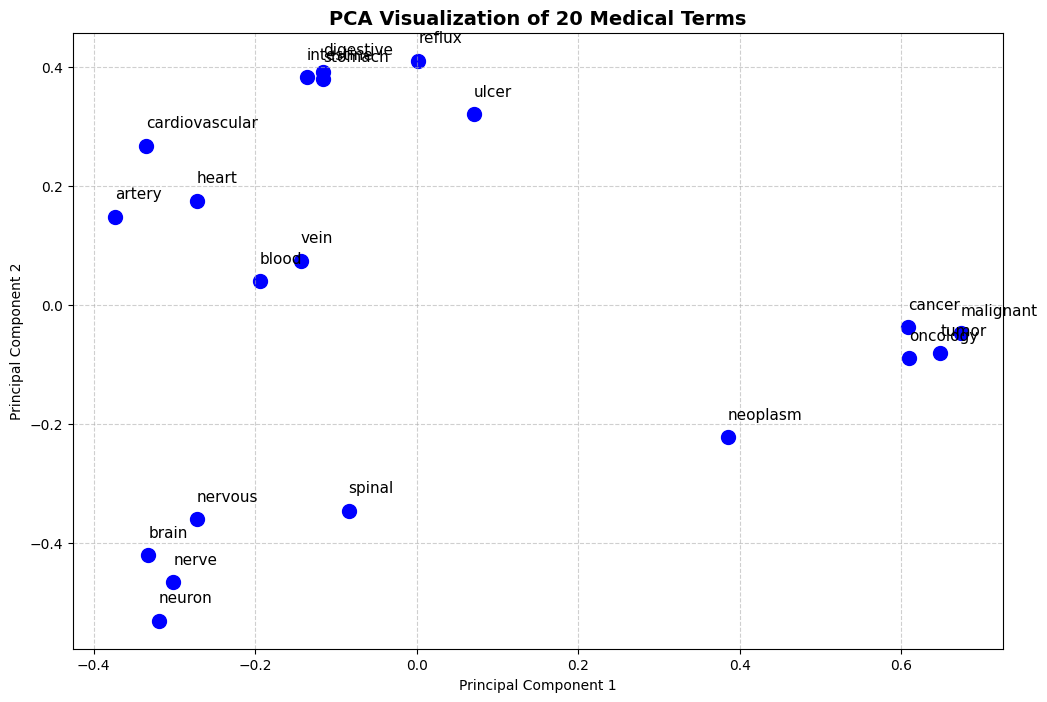

In [3]:
# Install sentence-transformers
!pip install sentence-transformers

from sentence_transformers import SentenceTransformer
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

# 1. Generate 20 known words aligned with your 5 medical categories
words = [
    "neoplasm", "tumor", "cancer", "oncology", "malignant",
    "cardiovascular", "heart", "artery", "vein", "blood",
    "nervous", "brain", "neuron", "spinal", "nerve",
    "digestive", "stomach", "intestine", "ulcer", "reflux"
]

# 2. Load a lightweight pretrained model to get word embeddings
print("Loading embedding model...")
model = SentenceTransformer('all-MiniLM-L6-v2')
embeddings = model.encode(words)

# 3. Visualize the vectors using PCA (reduce to 2 dimensions)
pca = PCA(n_components=2)
vectors_2d = pca.fit_transform(embeddings)

# 4. Plot the graph
plt.figure(figsize=(12, 8))
plt.scatter(vectors_2d[:, 0], vectors_2d[:, 1], c='blue', marker='o', s=100)

# Annotate each point with its corresponding word
for i, word in enumerate(words):
    plt.annotate(word, (vectors_2d[i, 0], vectors_2d[i, 1] + 0.03), fontsize=11)

plt.title("PCA Visualization of 20 Medical Terms", fontsize=14, fontweight='bold')
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()